# Fixed-window ready cohorts in public agent traces

## tl;dr

This notebook asks a stricter question than “are there many agents?”: **how
many same-operator events are ready at the same time?** It replays a pinned,
content-free 851-session tau2 trace panel under stationary swarm load and
measures the event share that can form cohorts of at least `K` within a fixed
latency window.

At 100,000 mean active sessions and a candidate crossover `K=256`, pooling all
events makes 85.6% eligible in a 25 ms window, while exact-route grouping makes
0% eligible. Exact routes reach only 30.3% at 50 ms and 47.9% at 100 ms. The
gap is the empirical regularity tax: population-scale parallelism is not the
same as GPU-ready parallelism. The result is exact for the frozen
non-overlapping partition; arbitrary sliding deadlines require the separate
packing bounds in `paper/formalism.md`.

## Context & Methods

The source panel is the complete tau2 subset of
`Exgentic/agent-llm-traces` at revision
`70036b93a04e61b0ea2706a68b962f4f26774587`. Derived features contain
timestamps, counts, lengths, route labels, and public identifiers, but no
prompt text, tool arguments, or tool results.

Each recorded span completion is a candidate control event. Independent
session arrivals follow a stationary Poisson process. The arrival rate is set
so the expected active session population equals `C`; empirical session
templates retain their relative timing and route sequence. Events are assigned
to fixed microbatch windows under three nested execution models:

1. **pooled** — a hypothetical universal transition can fuse every event;
2. **event class** — final/text, tool call, and error events are distinct;
3. **exact route** — every named tool route is distinct.

Eligibility is event-weighted: an event is eligible at threshold `K` if its
same-group cohort contains at least `K` events. The design, hypotheses,
thresholds, and exclusions were frozen in
`preregistration/trace-replay-001.md` before cohort computation.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROCESSED_DIR = ROOT / "data/processed"
FIGURE_DIR = ROOT / "results/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

spans = pd.read_parquet(PROCESSED_DIR / "exgentic-tau2-span-features.parquet")
sessions = pd.read_csv(PROCESSED_DIR / "exgentic-tau2-session-summary.csv")
repetitions = pd.read_csv(PROCESSED_DIR / "trace-ready-cohort-repetitions.csv")
summary = pd.read_csv(PROCESSED_DIR / "trace-ready-cohort-summary.csv")
source_manifest = json.loads(
    (PROCESSED_DIR / "exgentic-tau2-source-manifest.json").read_text()
)
replay_manifest = json.loads(
    (PROCESSED_DIR / "trace-ready-cohort-manifest.json").read_text()
)

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {
    "pooled": "#0B6E75",
    "event_class": "#D97706",
    "route_key": "#7C3AED",
}

len(spans), len(sessions), len(repetitions), len(summary)

(9031, 851, 3780, 756)

## Data quality

In [2]:
replay_runs = repetitions.drop_duplicates(["target_active_sessions", "repetition"])
quality = pd.DataFrame(
    {
        "measure": [
            "sessions",
            "events",
            "duplicate session IDs",
            "invalid JSON fields",
            "failed/nonpositive spans retained",
            "replay repetitions per population",
            "minimum realized/target active ratio",
            "maximum realized/target active ratio",
        ],
        "value": [
            len(sessions),
            len(spans),
            int(sessions["session_id"].duplicated().sum()),
            int(sessions["invalid_json_fields"].sum()),
            int(sessions["failed_status_spans"].sum()),
            int(replay_runs.groupby("target_active_sessions").size().min()),
            replay_runs["active_population_ratio"].min(),
            replay_runs["active_population_ratio"].max(),
        ],
    }
)
quality

,measure,value
0,sessions,851.000000
1,events,9031.000000
2,duplicate session IDs,0.000000
3,invalid JSON fields,0.000000
4,failed/nonpositive spans retained,52.000000
5,replay repetitions per population,5.000000
6,minimum realized/target active ratio,0.930942
7,maximum realized/target active ratio,1.122185


In [3]:
required = ["session_id", "benchmark", "harness", "ready_offset_s", "route_key"]
assert spans[required].isna().sum().sum() == 0
assert sessions["session_id"].is_unique
assert source_manifest["source_revision"] == "70036b93a04e61b0ea2706a68b962f4f26774587"
assert replay_manifest["quality"]["grouping_hierarchy_checked"] is True
assert set(replay_runs.groupby("target_active_sessions").size()) == {5}

hierarchy = summary.pivot_table(
    index=["target_active_sessions", "window_ms", "threshold_k"],
    columns="grouping",
    values="eligible_share_mean",
)
assert (hierarchy["pooled"] + 1e-12 >= hierarchy["event_class"]).all()
assert (hierarchy["event_class"] + 1e-12 >= hierarchy["route_key"]).all()

active_validation = (
    replay_runs.groupby("target_active_sessions")["active_population_ratio"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)
active_validation

,target_active_sessions,mean,std,min,max
0,100,0.983598,0.080759,0.930942,1.122185
1,1000,0.999549,0.042638,0.957593,1.062544
2,10000,0.999054,0.009834,0.986326,1.013698
3,100000,1.000317,0.004727,0.993267,1.006573


The low-population replay has wider Monte Carlo variation because only about
ten events per second are observed at `C=100`. The two largest populations,
which drive the crossover analysis, realize their target active population to
within roughly 1.4% in every repetition.

## Workload structure

In [4]:
session_structure = sessions[
    [
        "span_count",
        "session_duration_s",
        "route_count",
        "dominant_route_share",
        "effective_route_count",
        "peak_recorded_span_concurrency",
    ]
].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T
session_structure

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
span_count,851.0,10.612221,7.408424,2.000000,4.000000,6.000000,9.000000,13.00000,18.000000,25.000000,39.500000,54.000000
session_duration_s,851.0,97.666215,78.032675,5.987336,9.867134,36.279962,88.442634,134.58149,196.479367,242.367474,345.348258,575.502318
route_count,851.0,3.594595,3.397427,1.000000,1.000000,1.000000,1.000000,6.00000,8.000000,9.000000,15.000000,19.000000
dominant_route_share,851.0,0.766453,0.271167,0.200000,0.375000,0.500000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
effective_route_count,851.0,2.137493,1.446161,1.000000,1.000000,1.000000,1.000000,3.37931,4.333333,4.820000,5.562334,7.200000
peak_recorded_span_concurrency,851.0,1.128085,0.354863,1.000000,1.000000,1.000000,1.000000,1.00000,2.000000,2.000000,2.000000,3.000000


In [5]:
route_frequency = (
    spans.groupby(["event_class", "route_key"], as_index=False)
    .size()
    .sort_values("size", ascending=False)
)
route_frequency["event_share"] = route_frequency["size"] / len(spans)
route_frequency.head(20)

,event_class,route_key,size,event_share
1,final_or_text,final_or_text,4319,0.478242
45,tool_call,tool:mcp__environment__message,1635,0.181043
39,tool_call,tool:mcp__environment__get_order_details,366,0.040527
2,tool_call,tool:<multi>,325,0.035987
42,tool_call,tool:mcp__environment__get_user_details,222,0.024582
41,tool_call,tool:mcp__environment__get_reservation_details,152,0.016831
40,tool_call,tool:mcp__environment__get_product_details,138,0.015281
5,tool_call,tool:can_send_mms,131,0.014506
33,tool_call,tool:mcp__environment__find_user_id_by_name_zip,128,0.014173
37,tool_call,tool:mcp__environment__get_details_by_id,121,0.013398


The route distribution is concentrated but not homogeneous. Final/text events
are the largest exact route, while tool calls split across a long tail of named
operators. That distinction is precisely what pooled synthetic batches hide.

## Results

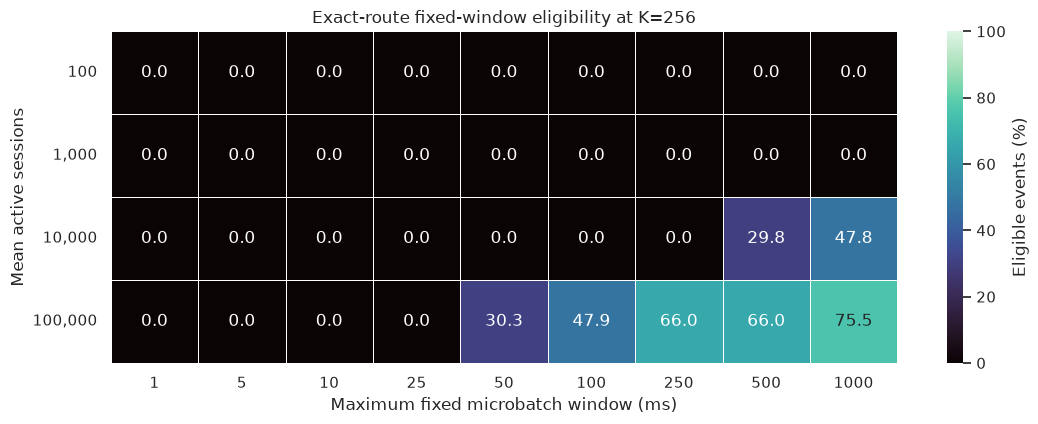

In [6]:
k = 256
exact = summary[(summary["grouping"] == "route_key") & (summary["threshold_k"] == k)]
heatmap = exact.pivot(
    index="target_active_sessions", columns="window_ms", values="eligible_share_mean"
)

fig, axis = plt.subplots(figsize=(11.2, 4.4))
sns.heatmap(
    heatmap * 100,
    annot=True,
    fmt=".1f",
    cmap="mako",
    vmin=0,
    vmax=100,
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Eligible events (%)"},
    ax=axis,
)
axis.set_title("Exact-route fixed-window eligibility at K=256")
axis.set_xlabel("Maximum fixed microbatch window (ms)")
axis.set_ylabel("Mean active sessions")
axis.set_yticklabels([f"{int(value):,}" for value in heatmap.index], rotation=0)
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURE_DIR / f"trace-ready-cohort-exact-k256-heatmap.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

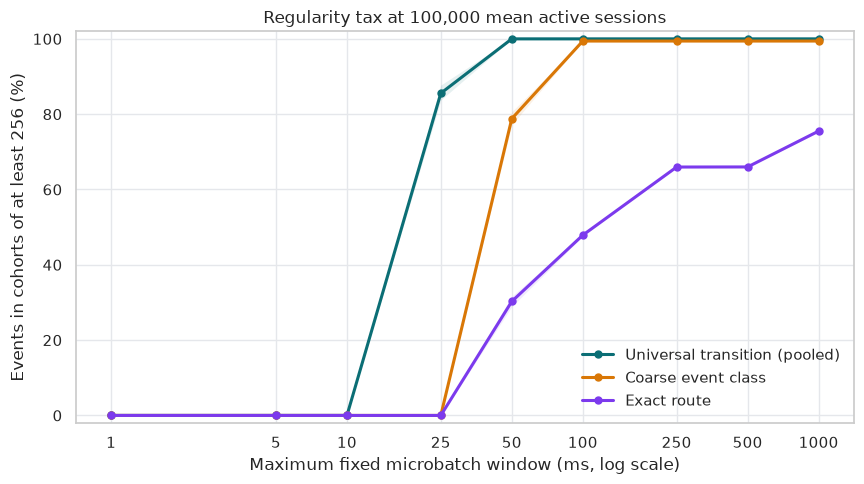

In [7]:
frontier = summary[
    (summary["target_active_sessions"] == 100_000)
    & (summary["threshold_k"] == 256)
].copy()

fig, axis = plt.subplots(figsize=(8.8, 5.0))
for grouping, label in [
    ("pooled", "Universal transition (pooled)"),
    ("event_class", "Coarse event class"),
    ("route_key", "Exact route"),
]:
    series = frontier[frontier["grouping"] == grouping].sort_values("window_ms")
    axis.plot(
        series["window_ms"],
        series["eligible_share_mean"] * 100,
        marker="o",
        linewidth=2.2,
        markersize=5,
        color=PALETTE[grouping],
        label=label,
    )
    axis.fill_between(
        series["window_ms"],
        series["eligible_share_min"] * 100,
        series["eligible_share_max"] * 100,
        color=PALETTE[grouping],
        alpha=0.10,
        linewidth=0,
    )
axis.set_xscale("log")
axis.set_xticks(sorted(frontier["window_ms"].unique()))
axis.xaxis.set_major_formatter(FuncFormatter(lambda value, _position: f"{value:g}"))
axis.set_ylim(-2, 102)
axis.set_xlabel("Maximum fixed microbatch window (ms, log scale)")
axis.set_ylabel("Events in cohorts of at least 256 (%)")
axis.set_title("Regularity tax at 100,000 mean active sessions")
axis.legend(frameon=False, loc="lower right")
axis.grid(True, which="major", color="#E5E7EB")
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURE_DIR / f"trace-ready-cohort-grouping-frontier-k256.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

In [8]:
selected = frontier.pivot(
    index="window_ms", columns="grouping", values="eligible_share_mean"
)
selected["pooled_minus_exact"] = selected["pooled"] - selected["route_key"]
selected["coarse_minus_exact"] = selected["event_class"] - selected["route_key"]
(selected * 100).round(1)

grouping,event_class,pooled,route_key,pooled_minus_exact,coarse_minus_exact
window_ms,,,,,
1,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,0.0,0.0
25,0.0,85.6,0.0,85.6,0.0
50,78.8,100.0,30.3,69.7,48.5
100,99.4,100.0,47.9,52.1,51.5
250,99.4,100.0,66.0,34.0,33.5
500,99.4,100.0,66.0,34.0,33.4
1000,99.4,100.0,75.5,24.5,23.9


In [9]:
threshold_frontier = summary[
    (summary["target_active_sessions"] == 100_000)
    & (summary["grouping"] == "route_key")
].pivot(index="threshold_k", columns="window_ms", values="eligible_share_mean")
(threshold_frontier * 100).round(1)

window_ms,1,5,10,25,50,100,250,500,1000
threshold_k,,,,,,,,,
32,0.0,9.0,48.0,65.9,66.2,73.8,83.8,89.4,95.8
64,0.0,0.0,3.6,48.5,66.0,66.0,75.3,83.9,89.2
128,0.0,0.0,0.0,29.5,47.9,66.0,66.2,75.4,84.1
256,0.0,0.0,0.0,0.0,30.3,47.9,66.0,66.0,75.5
512,0.0,0.0,0.0,0.0,0.0,32.4,51.2,66.0,66.0
1024,0.0,0.0,0.0,0.0,0.0,0.0,47.9,49.5,66.0
4096,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.9


In [10]:
milestones = []
for grouping in ["pooled", "event_class", "route_key"]:
    for window_ms in sorted(summary["window_ms"].unique()):
        candidates = summary[
            (summary["grouping"] == grouping)
            & (summary["threshold_k"] == 256)
            & (summary["window_ms"] == window_ms)
            & (summary["eligible_share_mean"] >= 0.50)
        ].sort_values("target_active_sessions")
        milestones.append(
            {
                "grouping": grouping,
                "window_ms": window_ms,
                "smallest_tested_C_at_50pct": (
                    None if candidates.empty else int(candidates.iloc[0]["target_active_sessions"])
                ),
            }
        )
pd.DataFrame(milestones).pivot(
    index="grouping", columns="window_ms", values="smallest_tested_C_at_50pct"
)

window_ms,1,5,10,25,50,100,250,500,1000
grouping,,,,,,,,,
event_class,NaN,NaN,NaN,NaN,100000.0,100000.0,100000.0,10000.0,10000.0
pooled,NaN,NaN,NaN,100000.0,100000.0,100000.0,10000.0,10000.0,10000.0
route_key,NaN,NaN,NaN,NaN,NaN,NaN,100000.0,100000.0,100000.0


## Takeaways

1. **Readiness, not population, is the binding quantity.** At `K=256`, exact
   routes do not reach 50% eligibility anywhere below the tested combination
   of 100,000 active sessions and a 250 ms window.
2. **Heterogeneity can erase an apparent GPU opportunity.** At 100,000 active
   sessions and 25 ms, a universal pooled kernel sees 85.6% eligible events;
   exact routes see none. At 50 ms the corresponding values are 100.0% and
   30.3%.
3. **Lowering the hardware crossover is extremely valuable.** At 100,000
   active sessions and 10 ms, exact-route eligibility is 48.0% for `K=32`,
   3.6% for `K=64`, and zero for `K>=128`.
4. **Longer windows eventually expose the route-frequency boundary.** At one
   second and `K=4096`, 47.9% of events are eligible—the share dominated by the
   single largest route—while the rest remain fragmented.
5. **This is fixed-window eligibility, not a universal ceiling or end-to-end
   speedup claim.** A sliding-deadline scheduler can form cohorts across a
   frozen boundary. Kernel cost, transfers, compilation, external queueing,
   tool capacity, and task utility also remain to be measured. The
   compiler-matched hardware pilots provide the `K` side of the equation; this
   trace study provides one controlled workload-side policy.